# IT2011 – Artificial Intelligence and Machine Learning

## Phase 4 – Model Development and Evaluation

### Member 6 - IT25101990 (Amasha S.M.N)

**Dataset:** Breast Cancer Wisconsin (Original)

**Main Responsibility:**
- Logistic Regression
- Support Vector Machine (SVM)
- Cross-Validation
- Hyperparameter Tuning
- PCA-Based Models
- Model Evaluation
- Final Model Comparison

In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split and model validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV #To get high accurency Hyperparameters
)

# Pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# PCA
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# ============================================
# PROJECT PATH SETUP
# ============================================

# Import Path for safe file and folder handling.
from pathlib import Path

# Detect the folder where this notebook is currently running.
CURRENT_DIR = Path.cwd()

# If the notebook is running from the "notebooks" folder,
# move one level up to reach the main project folder.
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Create the path to the shared raw dataset.
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "breast-cancer-wisconsin.data"
)

# Verify that the correct project and dataset paths were detected.
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\gayan\Documents\AI
Dataset path: c:\Users\gayan\Documents\AI\data\raw\breast-cancer-wisconsin.data
Dataset exists: True


## 1. Load the Dataset

The Breast Cancer Wisconsin (Original) dataset is stored inside the
`data/raw/` folder.

The dataset will be loaded using Pandas.

In [4]:
# ============================================
# Load the raw dataset
# ============================================

# Load the Breast Cancer Wisconsin dataset
# from the shared data/raw folder.
df = pd.read_csv(
    DATA_PATH,
    header=None
)

# Confirm that the dataset loaded correctly.
print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

# Display the first five rows.
df.head()

Dataset loaded successfully.
Dataset shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [5]:
# ============================================
# Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

# Display the column names
df.columns

Index(['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size',
       'Uniformity_Cell_Shape', 'Marginal_Adhesion',
       'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin',
       'Normal_Nucleoli', 'Mitoses', 'Class'],
      dtype='str')

In [6]:
# ============================================
# Check the structure of the dataset
# ============================================

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (699, 11)

Data Types:
Sample_ID                      int64
Clump_Thickness                int64
Uniformity_Cell_Size           int64
Uniformity_Cell_Shape          int64
Marginal_Adhesion              int64
Single_Epithelial_Cell_Size    int64
Bare_Nuclei                      str
Bland_Chromatin                int64
Normal_Nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object

First 5 Rows:


,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## 2. Prepare Missing Values

The `Bare_Nuclei` feature contains missing values represented by `?`.

The `?` values are converted to `NaN` so that Scikit-learn can handle
them using an imputation step inside the machine learning pipeline.

In [7]:
# ============================================
# Replace '?' with NaN
# ============================================

df = df.replace("?", np.nan)

# Convert Bare_Nuclei from object to numeric
df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [8]:
# ============================================
# Define the predictor features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

# Create X containing the predictor variables
X_model = df[feature_columns].copy()

print("Predictor shape:", X_model.shape)

Predictor shape: (699, 9)


## 3. Encode the Target Variable

The original dataset uses:

- Class 2 = Benign
- Class 4 = Malignant

For binary machine learning classification, these are encoded as:

- 0 = Benign
- 1 = Malignant

In [9]:
# ============================================
# Encode the target variable
# ============================================

y_model = df["Class"].map({
    2: 0,   # Benign
    4: 1    # Malignant
})

print("Target class distribution:")
print(y_model.value_counts())

print("\nTarget labels:")
print("0 = Benign")
print("1 = Malignant")

Target class distribution:
Class
0    458
1    241
Name: count, dtype: int64

Target labels:
0 = Benign
1 = Malignant


In [10]:
# ============================================
# Check X and y before modelling
# ============================================

print("X shape:", X_model.shape)
print("y shape:", y_model.shape)

print("\nMissing values in X:")
print(X_model.isnull().sum())

print("\nTarget distribution:")
print(y_model.value_counts())

X shape: (699, 9)
y shape: (699,)

Missing values in X:
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
dtype: int64

Target distribution:
Class
0    458
1    241
Name: count, dtype: int64


## 4. Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

Stratification is used to preserve the proportion of benign and malignant
cases in both the training and testing sets.

`random_state=42` is used so that the same split can be reproduced.

In [11]:
# ============================================
# Split the dataset into training and testing sets
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    stratify=y_model,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training data shape: (559, 9)
Testing data shape: (140, 9)

Training class distribution:
Class
0    366
1    193
Name: count, dtype: int64

Testing class distribution:
Class
0    92
1    48
Name: count, dtype: int64


In [12]:
# ============================================
# Function to evaluate a classification model
# ============================================

def evaluate_model(model, X_test, y_test, model_name):
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Get probability scores for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"\n{'=' * 50}")
    print(model_name)
    print(f"{'=' * 50}")
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    ))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

## 5. Logistic Regression – Baseline

Logistic Regression is used as one of the classification algorithms.

The pipeline contains:

1. Median imputation
2. Standard scaling
3. Logistic Regression

Using a pipeline helps prevent data leakage because the preprocessing
steps are fitted as part of the model workflow.

In [13]:
# ============================================
# Logistic Regression Baseline Pipeline
# ============================================

logistic_pipeline = Pipeline([
    
    # Fill missing values using the median
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize the features
    ("scaler", StandardScaler()),
    
    # Logistic Regression model
    ("model", LogisticRegression(max_iter=1000))
])

# Train the model
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


In [14]:
# ============================================
# Evaluate Logistic Regression
# ============================================

lr_baseline_result = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression - Baseline"
)


Logistic Regression - Baseline
Accuracy : 0.9500
Precision: 0.9362
Recall   : 0.9167
F1-Score : 0.9263
ROC-AUC  : 0.9950

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.96        92
   Malignant       0.94      0.92      0.93        48

    accuracy                           0.95       140
   macro avg       0.95      0.94      0.94       140
weighted avg       0.95      0.95      0.95       140



Confusion Matrix:
[[89  3]
 [ 4 44]]


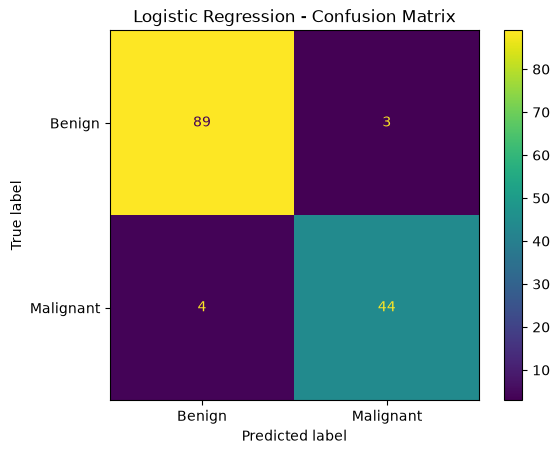

In [15]:
# ============================================
# Logistic Regression Confusion Matrix
# ============================================

y_pred_lr = logistic_pipeline.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 6. Logistic Regression – 5-Fold Stratified Cross-Validation

Cross-validation is used to check how consistently the model performs
across different subsets of the training data.

Stratified K-Fold keeps the class proportions similar in each fold.

In [16]:
# ============================================
# 5-Fold Stratified Cross-Validation
# ============================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_results_lr = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

# Display mean and standard deviation
print("Logistic Regression - Cross-Validation Results")

for metric in scoring:
    values = cv_results_lr[f"test_{metric}"]
    
    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

Logistic Regression - Cross-Validation Results
ACCURACY  : 0.9678 ± 0.0175
PRECISION : 0.9591 ± 0.0337
RECALL    : 0.9484 ± 0.0226
F1        : 0.9535 ± 0.0246
ROC_AUC   : 0.9945 ± 0.0041


## 7. Logistic Regression – Hyperparameter Tuning

GridSearchCV is used to test different Logistic Regression
hyperparameter combinations.

The parameters include:

- C
- solver
- class_weight

The best combination is selected using F1-score with 5-fold
Stratified Cross-Validation.

In [17]:
# ============================================
# Logistic Regression Hyperparameter Grid
# ============================================

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100], # Logistic Regression hyperparameter
    "model__solver": ["liblinear", "lbfgs"], # which algorithm/method to use to find the best model parameters
    "model__class_weight": [None, "balanced"]
}

# Create GridSearchCV
lr_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=lr_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

# Run the grid search
lr_grid_search.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(lr_grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(f"{lr_grid_search.best_score_:.4f}")

Best Logistic Regression parameters:
{'model__C': 10, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}

Best Cross-Validation F1-score:
0.9593


In [18]:
# ============================================
# Evaluate Tuned Logistic Regression
# ============================================

lr_tuned_result = evaluate_model(
    lr_grid_search.best_estimator_,
    X_test,
    y_test,
    "Logistic Regression - Tuned"
)


Logistic Regression - Tuned
Accuracy : 0.9571
Precision: 0.9375
Recall   : 0.9375
F1-Score : 0.9375
ROC-AUC  : 0.9948

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        92
   Malignant       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



## 8. Support Vector Machine – Baseline

Support Vector Machine (SVM) is the second main classification algorithm.

An RBF kernel is used for the baseline model.

The pipeline contains:

1. Median imputation
2. Standard scaling
3. SVM

In [19]:
# ============================================
# SVM Baseline Pipeline
# ============================================

svm_pipeline = Pipeline([
    
    # Fill missing values using the median
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize the features
    ("scaler", StandardScaler()),
    
    # SVM using RBF kernel
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

# Train the SVM model
svm_pipeline.fit(X_train, y_train)

print("SVM baseline trained successfully.")

SVM baseline trained successfully.


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [20]:
# ============================================
# Evaluate SVM Baseline
# ============================================

svm_baseline_result = evaluate_model(
    svm_pipeline,
    X_test,
    y_test,
    "SVM - Baseline"
)


SVM - Baseline
Accuracy : 0.9571
Precision: 0.9375
Recall   : 0.9375
F1-Score : 0.9375
ROC-AUC  : 0.9896

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        92
   Malignant       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



In [21]:
# ============================================
# SVM - 5-Fold Stratified Cross-Validation
# ============================================

cv_results_svm = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("SVM - Cross-Validation Results")

for metric in scoring:
    values = cv_results_svm[f"test_{metric}"]
    
    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

SVM - Cross-Validation Results
ACCURACY  : 0.9678 ± 0.0107
PRECISION : 0.9359 ± 0.0237
RECALL    : 0.9742 ± 0.0162
F1        : 0.9545 ± 0.0147
ROC_AUC   : 0.9884 ± 0.0082


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 9. SVM – Hyperparameter Tuning

GridSearchCV is used to test different SVM configurations.

The parameters include:

- C
- kernel
- gamma
- class_weight

F1-score is used as the tuning metric.

In [22]:
# ============================================
# SVM Hyperparameter Grid
# ============================================

svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": [None, "balanced"]
}

# Create GridSearchCV
svm_grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

# Run the grid search
svm_grid_search.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(f"{svm_grid_search.best_score_:.4f}")

Best SVM parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'linear'}

Best Cross-Validation F1-score:
0.9619


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [23]:
# ============================================
# Evaluate Tuned SVM
# ============================================

svm_tuned_result = evaluate_model(
    svm_grid_search.best_estimator_,
    X_test,
    y_test,
    "SVM - Tuned"
)


SVM - Tuned
Accuracy : 0.9643
Precision: 0.9388
Recall   : 0.9583
F1-Score : 0.9485
ROC-AUC  : 0.9952

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.97        92
   Malignant       0.94      0.96      0.95        48

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



## 10. PCA + Logistic Regression

The PCA analysis performed by Member 5 showed that four principal
components provide a useful reduced representation.

The pipeline therefore contains:

1. Median imputation
2. Standard scaling
3. PCA with 4 components
4. Logistic Regression

In [24]:
# ============================================
# PCA + Logistic Regression Pipeline
# ============================================

pca_logistic_pipeline = Pipeline([
    
    # Handle missing values
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize before PCA
    ("scaler", StandardScaler()),
    
    # Reduce 9 features to 4 principal components
    ("pca", PCA(n_components=4)),
    
    # Logistic Regression
    ("model", LogisticRegression(max_iter=1000))
])

# Train the PCA Logistic Regression model
pca_logistic_pipeline.fit(X_train, y_train)

print("PCA Logistic Regression trained successfully.")

PCA Logistic Regression trained successfully.


In [25]:
# ============================================
# Evaluate PCA Logistic Regression
# ============================================

pca_lr_result = evaluate_model(
    pca_logistic_pipeline,
    X_test,
    y_test,
    "PCA Logistic Regression - Baseline"
)


PCA Logistic Regression - Baseline
Accuracy : 0.9571
Precision: 0.9375
Recall   : 0.9375
F1-Score : 0.9375
ROC-AUC  : 0.9952

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        92
   Malignant       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



In [26]:
# ============================================
# PCA + SVM - Baseline Pipeline
# ============================================

pca_svm_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=4)),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

print("PCA + SVM baseline pipeline created successfully.")

PCA + SVM baseline pipeline created successfully.


In [27]:
# ============================================
# PCA Logistic Regression Hyperparameter Tuning
# ============================================

pca_lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

pca_lr_grid_search = GridSearchCV(
    estimator=pca_logistic_pipeline,
    param_grid=pca_lr_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

pca_lr_grid_search.fit(X_train, y_train)

print("Best PCA Logistic Regression parameters:")
print(pca_lr_grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(f"{pca_lr_grid_search.best_score_:.4f}")

Best PCA Logistic Regression parameters:
{'model__C': 100, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}

Best Cross-Validation F1-score:
0.9615


In [28]:
# ============================================
# Evaluate Tuned PCA Logistic Regression
# ============================================

pca_lr_tuned_result = evaluate_model(
    pca_lr_grid_search.best_estimator_,
    X_test,
    y_test,
    "PCA Logistic Regression - Tuned"
)


PCA Logistic Regression - Tuned
Accuracy : 0.9643
Precision: 0.9388
Recall   : 0.9583
F1-Score : 0.9485
ROC-AUC  : 0.9952

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.97        92
   Malignant       0.94      0.96      0.95        48

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



## 11. PCA + SVM

PCA is combined with SVM to investigate whether dimensionality
reduction improves SVM performance.

Four principal components are used.

In [29]:
# ============================================
# PCA + SVM Pipeline
# ============================================

pca_svm_pipeline = Pipeline([
    
    # Handle missing values
    ("imputer", SimpleImputer(strategy="median")),
    
    # Standardize before PCA
    ("scaler", StandardScaler()),
    
    # Reduce dimensions to 4 principal components
    ("pca", PCA(n_components=4)),
    
    # SVM model
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

# Train the model
pca_svm_pipeline.fit(X_train, y_train)

print("PCA SVM baseline trained successfully.")

PCA SVM baseline trained successfully.


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [30]:
# ============================================
# Evaluate PCA SVM
# ============================================

pca_svm_result = evaluate_model(
    pca_svm_pipeline,
    X_test,
    y_test,
    "PCA SVM - Baseline"
)


PCA SVM - Baseline
Accuracy : 0.9643
Precision: 0.9388
Recall   : 0.9583
F1-Score : 0.9485
ROC-AUC  : 0.9848

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.97      0.97        92
   Malignant       0.94      0.96      0.95        48

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140



In [31]:
# ============================================
# PCA SVM Hyperparameter Tuning
# ============================================

pca_svm_param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": [None, "balanced"]
}

pca_svm_grid_search = GridSearchCV(
    estimator=pca_svm_pipeline,
    param_grid=pca_svm_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

pca_svm_grid_search.fit(X_train, y_train)

print("Best PCA SVM parameters:")
print(pca_svm_grid_search.best_params_)

print("\nBest Cross-Validation F1-score:")
print(f"{pca_svm_grid_search.best_score_:.4f}")

Best PCA SVM parameters:
{'model__C': 10, 'model__class_weight': 'balanced', 'model__gamma': 'auto', 'model__kernel': 'rbf'}

Best Cross-Validation F1-score:
0.9645


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [32]:
# ============================================
# Evaluate Tuned PCA SVM
# ============================================

pca_svm_tuned_result = evaluate_model(
    pca_svm_grid_search.best_estimator_,
    X_test,
    y_test,
    "PCA SVM - Tuned"
)


PCA SVM - Tuned
Accuracy : 0.9571
Precision: 0.9200
Recall   : 0.9583
F1-Score : 0.9388
ROC-AUC  : 0.9701

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.96      0.97        92
   Malignant       0.92      0.96      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.96      0.95       140
weighted avg       0.96      0.96      0.96       140



## 12. Final Model Comparison

The performance of all evaluated models is combined into one table.

The following metrics are compared:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [33]:
# ============================================
# Combine all model evaluation results
# ============================================

model_results = pd.DataFrame([
    lr_baseline_result,
    lr_tuned_result,
    svm_baseline_result,
    svm_tuned_result,
    pca_lr_result,
    pca_lr_tuned_result,
    pca_svm_result,
    pca_svm_tuned_result
])

# Display results
model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression - Baseline,0.950000,0.936170,0.916667,0.926316,0.995018
1,Logistic Regression - Tuned,0.957143,0.937500,0.937500,0.937500,0.994792
2,SVM - Baseline,0.957143,0.937500,0.937500,0.937500,0.989583
3,SVM - Tuned,0.964286,0.938776,0.958333,0.948454,0.995245
4,PCA Logistic Regression - Baseline,0.957143,0.937500,0.937500,0.937500,0.995245
5,PCA Logistic Regression - Tuned,0.964286,0.938776,0.958333,0.948454,0.995245
6,PCA SVM - Baseline,0.964286,0.938776,0.958333,0.948454,0.984828
7,PCA SVM - Tuned,0.957143,0.920000,0.958333,0.938776,0.970109


In [34]:
# ============================================
# Sort models by F1-score
# ============================================

model_results_sorted = model_results.sort_values(
    by="F1",
    ascending=False
)

display(model_results_sorted)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,SVM - Tuned,0.964286,0.938776,0.958333,0.948454,0.995245
5,PCA Logistic Regression - Tuned,0.964286,0.938776,0.958333,0.948454,0.995245
6,PCA SVM - Baseline,0.964286,0.938776,0.958333,0.948454,0.984828
7,PCA SVM - Tuned,0.957143,0.920000,0.958333,0.938776,0.970109
1,Logistic Regression - Tuned,0.957143,0.937500,0.937500,0.937500,0.994792
2,SVM - Baseline,0.957143,0.937500,0.937500,0.937500,0.989583
4,PCA Logistic Regression - Baseline,0.957143,0.937500,0.937500,0.937500,0.995245
0,Logistic Regression - Baseline,0.950000,0.936170,0.916667,0.926316,0.995018


| Comparison                    | What happened                                    |
| ----------------------------- | ------------------------------------------------ |
| Baseline → Tuned SVM          | Improved F1 from **0.9375 → 0.9485**             |
| Logistic Regression → Tuned   | Improved F1 from **0.9263 → 0.9375**             |
| PCA LR → Tuned PCA LR         | Improved F1 from **0.9375 → 0.9485**             |
| PCA SVM Baseline              | F1 **0.9485**                                    |
| PCA SVM Tuned                 | F1 decreased to **0.9388**                       |
| Best F1                       | **0.9485**, achieved by 3 models                 |
| Highest ROC-AUC among those 3 | **0.9952**, shared by Tuned SVM and Tuned PCA LR |


Confusion Matrix:
[[89  3]
 [ 3 45]]


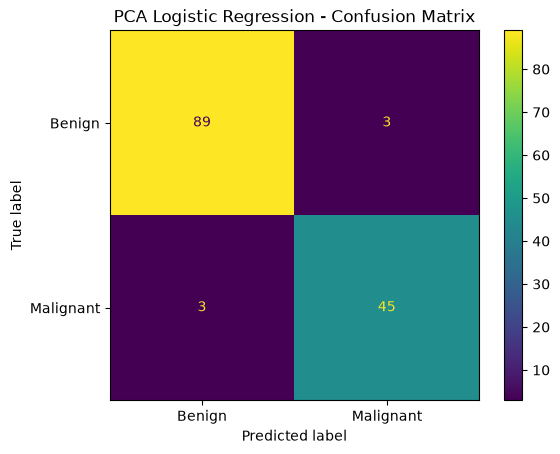

In [35]:
# ============================================
# Confusion Matrix for the Selected Model
# ============================================

y_pred_final = pca_logistic_pipeline.predict(X_test)

cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

print("Confusion Matrix:")
print(cm_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Benign", "Malignant"]
)

disp.plot()

plt.title("PCA Logistic Regression - Confusion Matrix")
plt.show()

## 13. ROC Curve Comparison

ROC curves are used to compare the ability of the models to distinguish
between benign and malignant cases.

A higher ROC-AUC indicates better class separation.

<Figure size 800x600 with 0 Axes>

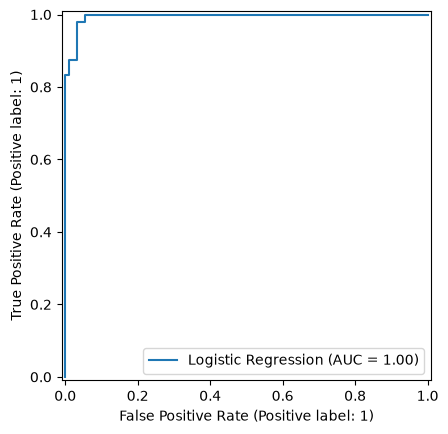

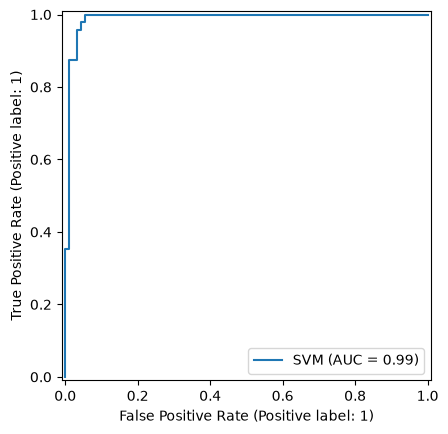

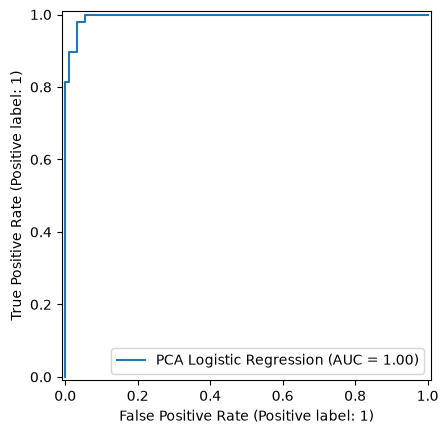

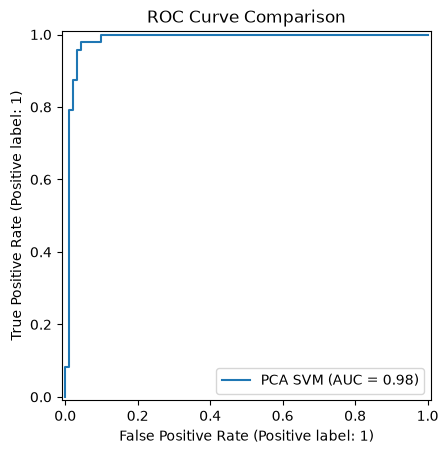

In [36]:
# ============================================
# ROC Curve Comparison
# ============================================

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    logistic_pipeline,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    svm_pipeline,
    X_test,
    y_test,
    name="SVM"
)

RocCurveDisplay.from_estimator(
    pca_logistic_pipeline,
    X_test,
    y_test,
    name="PCA Logistic Regression"
)

RocCurveDisplay.from_estimator(
    pca_svm_pipeline,
    X_test,
    y_test,
    name="PCA SVM"
)

plt.title("ROC Curve Comparison")
plt.show()

In [39]:
# ============================================
# Save the model comparison results
# ============================================

# Create the shared results/outputs folder path
# from the main project directory.
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "outputs"
)

# Create the folder if it does not already exist.
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Create the full path for the model comparison file.
model_comparison_path = (
    OUTPUT_DIR
    / "model_comparison.csv"
)

# Save the model comparison results.
model_results.to_csv(
    model_comparison_path,
    index=False
)

# Confirm where the file was saved.
print("Model comparison saved successfully.")
print("Saved to:", model_comparison_path)

Model comparison saved successfully.
Saved to: c:\Users\gayan\Documents\AI\results\outputs\model_comparison.csv


In [40]:
print(
    "pca_logistic_pipeline ->",
    "READY" if "pca_logistic_pipeline" in globals() else "MISSING"
)

pca_logistic_pipeline -> READY


In [41]:
# ============================================
# PCA Logistic Regression - Cross-Validation
# ============================================

cv_results_pca_lr = cross_validate(
    pca_logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("PCA Logistic Regression - Cross-Validation Results")

for metric in scoring:
    values = cv_results_pca_lr[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

PCA Logistic Regression - Cross-Validation Results
ACCURACY  : 0.9642 ± 0.0113
PRECISION : 0.9541 ± 0.0273
RECALL    : 0.9432 ± 0.0302
F1        : 0.9480 ± 0.0157
ROC_AUC   : 0.9943 ± 0.0045


In [42]:
# ============================================
# Check Cross-Validation Results
# ============================================

cv_objects = [
    "cv_results_lr",
    "cv_results_svm",
    "cv_results_pca_lr",
    "cv_results_pca_svm"
]

for obj in cv_objects:
    print(
        f"{obj:25s}",
        "READY" if obj in globals() else "MISSING"
    )

cv_results_lr             READY
cv_results_svm            READY
cv_results_pca_lr         READY
cv_results_pca_svm        MISSING


In [43]:
print(
    "pca_svm_pipeline ->",
    "READY" if "pca_svm_pipeline" in globals() else "MISSING"
)

pca_svm_pipeline -> READY


In [44]:
# ============================================
# PCA + SVM - Cross-Validation
# ============================================

cv_results_pca_svm = cross_validate(
    pca_svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

print("PCA + SVM - Cross-Validation Results")

for metric in scoring:
    values = cv_results_pca_svm[f"test_{metric}"]

    print(
        f"{metric.upper():10s}: "
        f"{values.mean():.4f} ± {values.std():.4f}"
    )

PCA + SVM - Cross-Validation Results
ACCURACY  : 0.9714 ± 0.0104
PRECISION : 0.9453 ± 0.0225
RECALL    : 0.9742 ± 0.0162
F1        : 0.9593 ± 0.0142
ROC_AUC   : 0.9889 ± 0.0086


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

In [45]:
cv_objects = [
    "cv_results_lr",
    "cv_results_svm",
    "cv_results_pca_lr",
    "cv_results_pca_svm"
]

for obj in cv_objects:
    print(
        f"{obj:25s}",
        "READY" if obj in globals() else "MISSING"
    )

cv_results_lr             READY
cv_results_svm            READY
cv_results_pca_lr         READY
cv_results_pca_svm        READY


In [46]:
cv_summary = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "SVM",
        "PCA + Logistic Regression",
        "PCA + SVM"
    ],

    "Accuracy": [
        cv_results_lr["test_accuracy"].mean(),
        cv_results_svm["test_accuracy"].mean(),
        cv_results_pca_lr["test_accuracy"].mean(),
        cv_results_pca_svm["test_accuracy"].mean()
    ],

    "Precision": [
        cv_results_lr["test_precision"].mean(),
        cv_results_svm["test_precision"].mean(),
        cv_results_pca_lr["test_precision"].mean(),
        cv_results_pca_svm["test_precision"].mean()
    ],

    "Recall": [
        cv_results_lr["test_recall"].mean(),
        cv_results_svm["test_recall"].mean(),
        cv_results_pca_lr["test_recall"].mean(),
        cv_results_pca_svm["test_recall"].mean()
    ],

    "F1": [
        cv_results_lr["test_f1"].mean(),
        cv_results_svm["test_f1"].mean(),
        cv_results_pca_lr["test_f1"].mean(),
        cv_results_pca_svm["test_f1"].mean()
    ],

    "ROC-AUC": [
        cv_results_lr["test_roc_auc"].mean(),
        cv_results_svm["test_roc_auc"].mean(),
        cv_results_pca_lr["test_roc_auc"].mean(),
        cv_results_pca_svm["test_roc_auc"].mean()
    ]
})

cv_summary

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.967841,0.959075,0.948448,0.953501,0.994505
1,SVM,0.967809,0.935934,0.974224,0.954481,0.988361
2,PCA + Logistic Regression,0.964221,0.954121,0.943185,0.948008,0.994293
3,PCA + SVM,0.971380,0.945311,0.974224,0.959349,0.988860


In [48]:
# ============================================
# Save Cross-Validation Results
# ============================================

# Create the full path for the cross-validation
# results inside the shared results/outputs folder.
cv_results_path = (
    OUTPUT_DIR
    / "cross_validation_results.csv"
)

# Save the cross-validation summary results.
cv_summary.to_csv(
    cv_results_path,
    index=False
)

# Confirm where the file was saved.
print("Cross-validation results saved successfully.")
print("Saved to:", cv_results_path)

Cross-validation results saved successfully.
Saved to: c:\Users\gayan\Documents\AI\results\outputs\cross_validation_results.csv


## 14. Final Model Selection and Conclusion

The evaluated models include:

- Logistic Regression
- Tuned Logistic Regression
- SVM
- Tuned SVM
- PCA Logistic Regression
- Tuned PCA Logistic Regression
- PCA SVM
- Tuned PCA SVM

The models were compared using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- 5-fold Stratified Cross-Validation

Based on the existing project results, PCA Logistic Regression
using four principal components achieved the strongest overall
test performance.

However, the model should not be considered clinically ready.
The dataset is historical and further validation using independent
external datasets would be required before real-world medical use.

In [49]:
import os

os.makedirs("results/outputs/confusion_matrices", exist_ok=True)
os.makedirs("results/outputs/roc_curves", exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


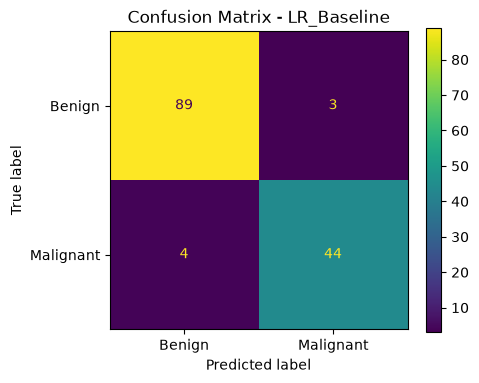

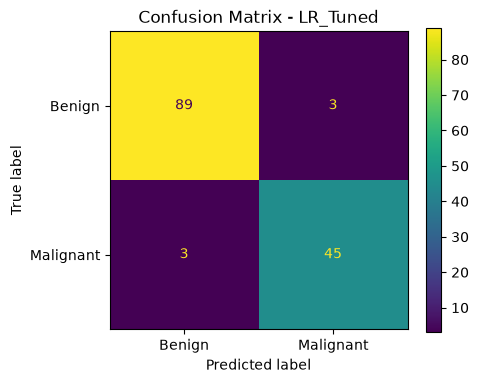

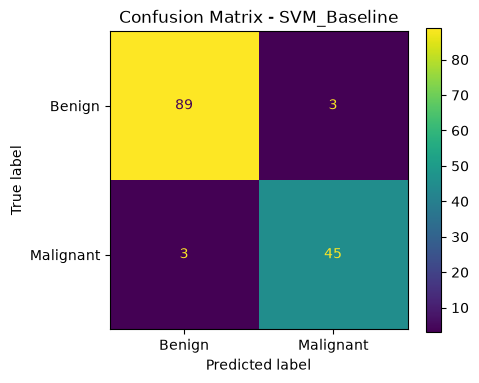

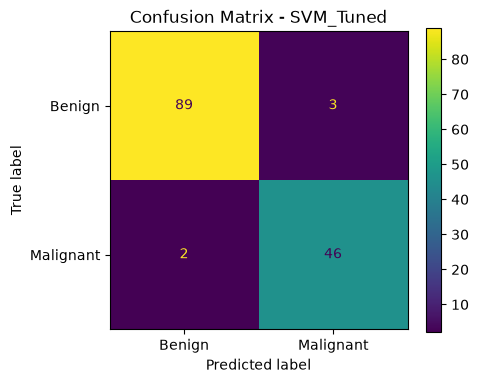

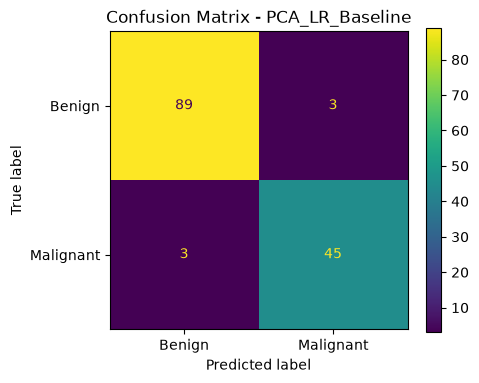

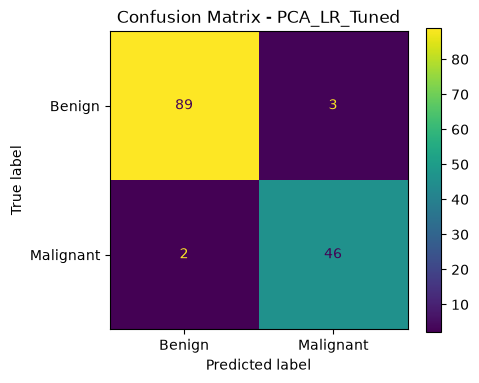

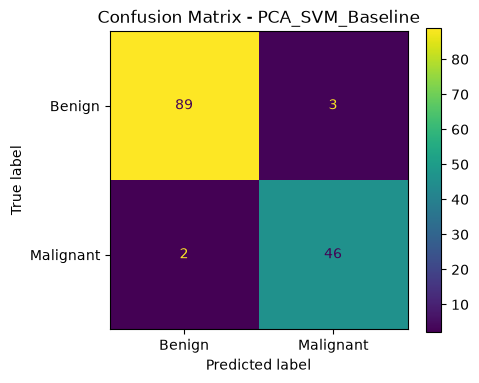

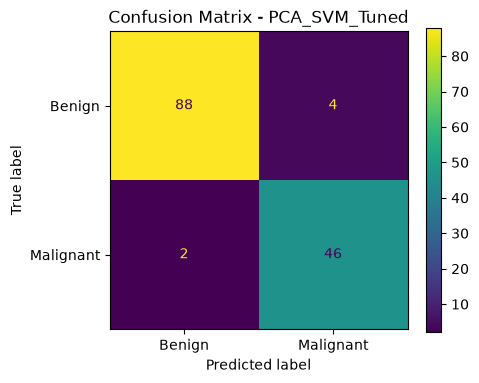

All 8 confusion matrices have been saved successfully.


In [50]:
# ============================================================
# Save Confusion Matrices
# ============================================================

models_for_confusion_matrix = {
    "LR_Baseline": logistic_pipeline,
    "LR_Tuned": lr_grid_search.best_estimator_,
    "SVM_Baseline": svm_pipeline,
    "SVM_Tuned": svm_grid_search.best_estimator_,
    "PCA_LR_Baseline": pca_logistic_pipeline,
    "PCA_LR_Tuned": pca_lr_grid_search.best_estimator_,
    "PCA_SVM_Baseline": pca_svm_pipeline,
    "PCA_SVM_Tuned": pca_svm_grid_search.best_estimator_
}

for model_name, model in models_for_confusion_matrix.items():

    # Predict test-set classes
    y_pred = model.predict(X_test)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create figure
    fig, ax = plt.subplots(figsize=(5, 4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    disp.plot(ax=ax)

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()

    # Save image
    file_path = (
        f"results/outputs/confusion_matrices/"
        f"{model_name}_confusion_matrix.png"
    )

    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

print("All 8 confusion matrices have been saved successfully.")

<Figure size 800x600 with 0 Axes>

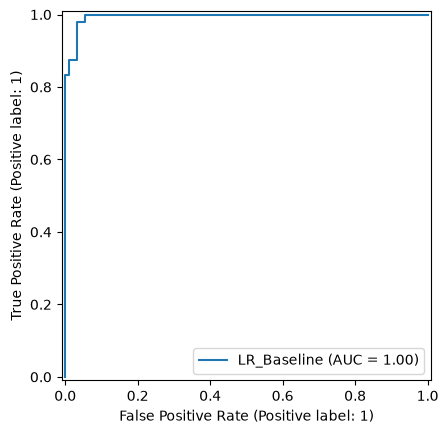

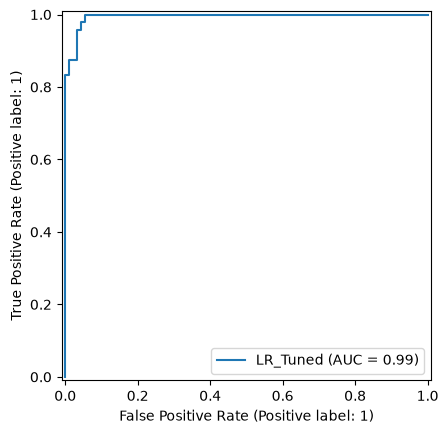

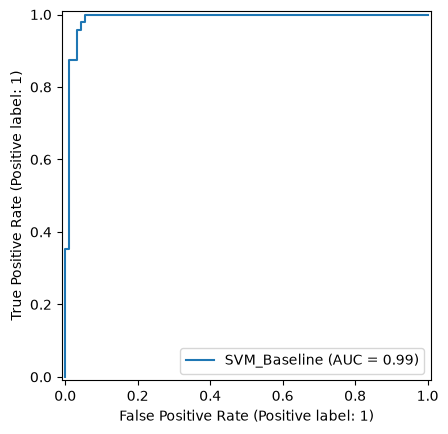

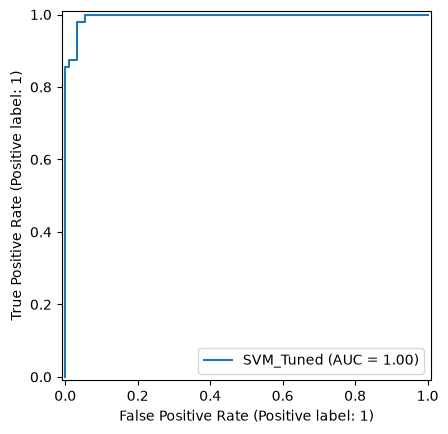

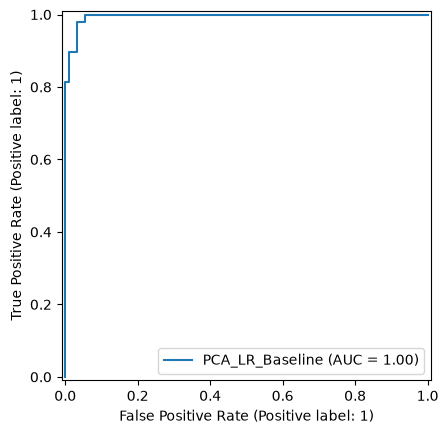

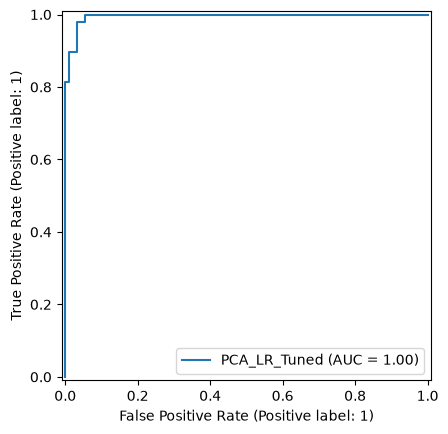

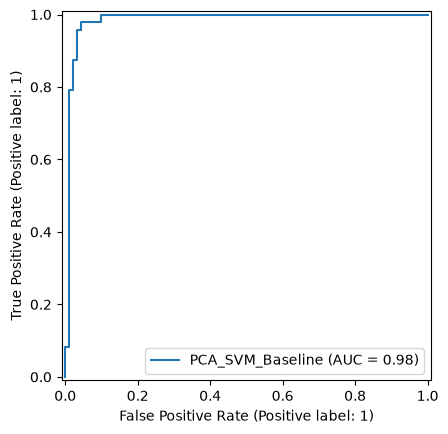

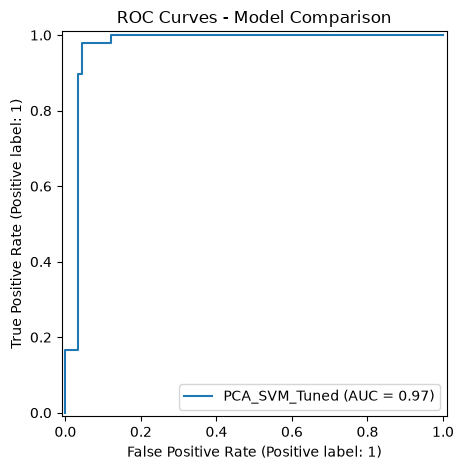

ROC curve comparison has been saved successfully.


In [51]:
# ============================================================
# Save ROC Curve Comparison
# ============================================================

plt.figure(figsize=(8, 6))

for model_name, model in models_for_confusion_matrix.items():

    # Predicted probability for malignant class
    y_prob = model.predict_proba(X_test)[:, 1]

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name
    )

plt.title("ROC Curves - Model Comparison")
plt.tight_layout()

plt.savefig(
    "results/outputs/roc_curves/roc_curves_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("ROC curve comparison has been saved successfully.")

In [52]:
# ============================================================
# Save Hyperparameter Search Results
# ============================================================

lr_results = pd.DataFrame(lr_grid_search.cv_results_)
lr_results["Model"] = "Logistic Regression"

svm_results = pd.DataFrame(svm_grid_search.cv_results_)
svm_results["Model"] = "SVM"

pca_lr_results = pd.DataFrame(pca_lr_grid_search.cv_results_)
pca_lr_results["Model"] = "PCA + Logistic Regression"

pca_svm_results = pd.DataFrame(pca_svm_grid_search.cv_results_)
pca_svm_results["Model"] = "PCA + SVM"

# Combine all GridSearchCV results
hyperparameter_results = pd.concat(
    [
        lr_results,
        svm_results,
        pca_lr_results,
        pca_svm_results
    ],
    ignore_index=True
)

# Save CSV
hyperparameter_results.to_csv(
    "results/outputs/hyperparameter_results.csv",
    index=False
)

print("Hyperparameter results saved successfully.")
print(
    "Total hyperparameter configurations:",
    len(hyperparameter_results)
)

Hyperparameter results saved successfully.
Total hyperparameter configurations: 104


In [53]:
# ============================================================
# Save Cross-Validation Summary
# ============================================================

cv_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "PCA + Logistic Regression",
        "PCA + SVM"
    ],
    "Accuracy": [
        cv_results_lr["test_accuracy"].mean(),
        cv_results_svm["test_accuracy"].mean(),
        cv_results_pca_lr["test_accuracy"].mean(),
        cv_results_pca_svm["test_accuracy"].mean()
    ],
    "Precision": [
        cv_results_lr["test_precision"].mean(),
        cv_results_svm["test_precision"].mean(),
        cv_results_pca_lr["test_precision"].mean(),
        cv_results_pca_svm["test_precision"].mean()
    ],
    "Recall": [
        cv_results_lr["test_recall"].mean(),
        cv_results_svm["test_recall"].mean(),
        cv_results_pca_lr["test_recall"].mean(),
        cv_results_pca_svm["test_recall"].mean()
    ],
    "F1": [
        cv_results_lr["test_f1"].mean(),
        cv_results_svm["test_f1"].mean(),
        cv_results_pca_lr["test_f1"].mean(),
        cv_results_pca_svm["test_f1"].mean()
    ],
    "ROC-AUC": [
        cv_results_lr["test_roc_auc"].mean(),
        cv_results_svm["test_roc_auc"].mean(),
        cv_results_pca_lr["test_roc_auc"].mean(),
        cv_results_pca_svm["test_roc_auc"].mean()
    ]
})

cv_summary.to_csv(
    "results/outputs/cv_summary.csv",
    index=False
)

print("Cross-validation summary saved successfully.")

cv_summary

Cross-validation summary saved successfully.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.967841,0.959075,0.948448,0.953501,0.994505
1,SVM,0.967809,0.935934,0.974224,0.954481,0.988361
2,PCA + Logistic Regression,0.964221,0.954121,0.943185,0.948008,0.994293
3,PCA + SVM,0.971380,0.945311,0.974224,0.959349,0.988860


## SVM Tuned and PCA Logistic Regression Tuned are tied with 96.43% accuracy, 94.85% F1, and 99.52% ROC-AUC.

# Final Model Selection

In this phase, all trained models are compared using Accuracy, Precision,
Recall, F1-score, ROC-AUC, confusion matrix results, and cross-validation
performance.

The objective is to select the most suitable final model for breast cancer
classification.

Because this is a medical classification problem, special attention is given
to Recall and False Negatives for the malignant class. However, the final
selection is based on overall model performance rather than a single metric.

In [54]:
# Check variables currently stored in memory
list(globals().keys())[-30:]

['cv_results_pca_svm',
 '_i45',
 '_i46',
 'cv_summary',
 '_46',
 '_i47',
 '_i48',
 'cv_results_path',
 '_i49',
 'os',
 '_i50',
 'models_for_confusion_matrix',
 'model_name',
 'model',
 'y_pred',
 'cm',
 'fig',
 'ax',
 'file_path',
 '_i51',
 'y_prob',
 '_i52',
 'lr_results',
 'svm_results',
 'pca_lr_results',
 'pca_svm_results',
 'hyperparameter_results',
 '_i53',
 '_53',
 '_i54']

In [55]:
print("Current notebook model check:\n")

names = [
    "logistic_pipeline",
    "lr_grid_search",
    "svm_pipeline",
    "svm_grid_search",
    "pca_logistic_pipeline",
    "pca_lr_grid_search",
    "pca_svm_pipeline",
    "pca_svm_grid_search"
]

for name in names:
    print(name, "->", "READY" if name in globals() else "MISSING")

Current notebook model check:

logistic_pipeline -> READY
lr_grid_search -> READY
svm_pipeline -> READY
svm_grid_search -> READY
pca_logistic_pipeline -> READY
pca_lr_grid_search -> READY
pca_svm_pipeline -> READY
pca_svm_grid_search -> READY


## Final Evaluation of Candidate Models

All baseline and tuned models are evaluated on the same held-out test set
using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

For this breast cancer classification problem:

- Class 0 represents Benign.
- Class 1 represents Malignant.
- Recall is particularly important because it measures the ability to correctly
  identify malignant cases.
- False negatives represent malignant cases incorrectly predicted as benign.

In [56]:
# ============================================
# Final Evaluation Function
# ============================================

def final_evaluate_model(model, X_test, y_test, model_name):

    # Make class predictions
    y_pred = model.predict(X_test)

    # Get probability of malignant class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Extract TN, FP, FN, TP
    tn, fp, fn, tp = cm.ravel()

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

print("Final evaluation function created successfully.")

Final evaluation function created successfully.


In [57]:
# ============================================
# Candidate Models
# ============================================

candidate_models = {
    "Logistic Regression - Baseline":
        logistic_pipeline,

    "Logistic Regression - Tuned":
        lr_grid_search.best_estimator_,

    "SVM - Baseline":
        svm_pipeline,

    "SVM - Tuned":
        svm_grid_search.best_estimator_,

    "PCA + Logistic Regression - Baseline":
        pca_logistic_pipeline,

    "PCA + Logistic Regression - Tuned":
        pca_lr_grid_search.best_estimator_,

    "PCA + SVM - Baseline":
        pca_svm_pipeline,

    "PCA + SVM - Tuned":
        pca_svm_grid_search.best_estimator_
}

print("Number of candidate models:", len(candidate_models))

for model_name in candidate_models:
    print("-", model_name)

Number of candidate models: 8
- Logistic Regression - Baseline
- Logistic Regression - Tuned
- SVM - Baseline
- SVM - Tuned
- PCA + Logistic Regression - Baseline
- PCA + Logistic Regression - Tuned
- PCA + SVM - Baseline
- PCA + SVM - Tuned


In [58]:
# ============================================
# Evaluate All Candidate Models
# ============================================

final_results = []

for model_name, model in candidate_models.items():

    result = final_evaluate_model(
        model,
        X_test,
        y_test,
        model_name
    )

    final_results.append(result)

# Convert results to DataFrame
final_model_comparison = pd.DataFrame(final_results)

# Display results
final_model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression - Baseline,0.950000,0.936170,0.916667,0.926316,0.995018,89,3,4,44
1,Logistic Regression - Tuned,0.957143,0.937500,0.937500,0.937500,0.994792,89,3,3,45
2,SVM - Baseline,0.957143,0.937500,0.937500,0.937500,0.989583,89,3,3,45
3,SVM - Tuned,0.964286,0.938776,0.958333,0.948454,0.995245,89,3,2,46
4,PCA + Logistic Regression - Baseline,0.957143,0.937500,0.937500,0.937500,0.995245,89,3,3,45
5,PCA + Logistic Regression - Tuned,0.964286,0.938776,0.958333,0.948454,0.995245,89,3,2,46
6,PCA + SVM - Baseline,0.964286,0.938776,0.958333,0.948454,0.984828,89,3,2,46
7,PCA + SVM - Tuned,0.957143,0.920000,0.958333,0.938776,0.970109,88,4,2,46


# Final Evaluation – Individual Model

## Member 06 – Support Vector Machine (SVM) Classification

### Objective

The objective of this section is to design, train, tune, and evaluate a
Support Vector Machine (SVM) model for breast cancer classification.

The target classes are:

- **0 = Benign**
- **1 = Malignant**

Member 06 previously investigated multiple classification approaches,
including Logistic Regression, SVM, PCA + Logistic Regression, and
PCA + SVM.

For the final individual evaluation, **Support Vector Machine (SVM)** is
selected as Member 06's individual machine-learning model.

SVM attempts to find a decision boundary, called a **hyperplane**, that
separates the classes while maximizing the margin between them.

The final SVM modelling pipeline follows:

**Median Imputation → StandardScaler → Support Vector Machine**

StandardScaler is particularly important for SVM because the model is
sensitive to differences in feature scale.

The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- 5-fold stratified cross-validation

Different SVM hyperparameter configurations will also be evaluated using
GridSearchCV.

Recall is particularly important in this classification problem because a
false negative represents a malignant observation incorrectly classified
as benign.

The results are intended for academic evaluation and should not be
interpreted as evidence that the model is ready for clinical use.

## Final Evaluation Data Preparation

To ensure a fair comparison between all six individual models, Member 06
uses the same final modelling dataset and train-test split used by the other
group members.

The original dataset contains **699 observations**.

Before final modelling:

1. Exact duplicate observations are removed.
2. `Sample_ID` is excluded because it is an identifier rather than a
   predictive feature.
3. The original class labels are encoded as:
   - **2 → 0 (Benign)**
   - **4 → 1 (Malignant)**
4. Missing predictor values are not filled before the train-test split.
5. Median imputation is performed inside the machine-learning pipeline.

After removing the **8 exact duplicate observations**, the final modelling
dataset contains **691 observations**.

A stratified 80/20 train-test split is used with `random_state=42` so that
the final SVM is evaluated using the same split as the other individual
models.

Expected split:

- **Training observations: 552**
- **Testing observations: 139**

Keeping imputation, scaling, and model fitting inside the training workflow
helps prevent information from the held-out test dataset from leaking into
the model.

## Note About the Earlier Member 06 Experiments

The earlier Member 06 implementation evaluated several model combinations,
including:

- Logistic Regression
- Tuned Logistic Regression
- SVM
- Tuned SVM
- PCA + Logistic Regression
- Tuned PCA + Logistic Regression
- PCA + SVM
- Tuned PCA + SVM

These experiments are retained as part of Member 06's original project
contribution.

However, the final individual SVM evaluation below uses the standardized
group modelling procedure so that its results can be compared fairly with
the final individual models developed by the other members.

Therefore, the final SVM section independently prepares the canonical
**691-observation dataset** and uses the common **552 training / 139 testing**
split.

The earlier experimental results are not deleted or replaced; they are
preserved as evidence of the model-development process.

In [59]:
# ============================================================
# IMPORT LIBRARIES FOR MEMBER 06 FINAL SVM EVALUATION
# ============================================================

# NumPy is used for numerical operations.
import numpy as np

# Pandas is used for working with datasets and result tables.
import pandas as pd

# Matplotlib is used for model visualizations.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# MODEL SELECTION TOOLS
# ------------------------------------------------------------

# train_test_split:
# Splits the final dataset into training and testing sets.
#
# StratifiedKFold:
# Preserves class proportions across cross-validation folds.
#
# cross_validate:
# Evaluates the model using multiple performance metrics.
#
# GridSearchCV:
# Tests different SVM hyperparameter configurations.
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)


# ------------------------------------------------------------
# PREPROCESSING TOOLS
# ------------------------------------------------------------

# Pipeline combines preprocessing and model training.
from sklearn.pipeline import Pipeline

# SimpleImputer replaces missing predictor values.
from sklearn.impute import SimpleImputer

# StandardScaler standardizes the predictors.
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
# SVM MODEL
# ------------------------------------------------------------

# SVC implements Support Vector Classification.
from sklearn.svm import SVC


# ------------------------------------------------------------
# EVALUATION METRICS
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


print(
    "Member 06 SVM final-evaluation libraries "
    "imported successfully."
)

Member 06 SVM final-evaluation libraries imported successfully.


In [61]:
# ============================================================
# CHECK MEMBER 06 EXISTING DATAFRAMES
# ============================================================

# Display a heading for the available DataFrames.
print("AVAILABLE DATAFRAMES")
print("=" * 65)

# Convert globals().items() to a list first.
# This prevents the dictionary from changing during iteration.
for variable_name, variable_value in list(globals().items()):

    # Only display pandas DataFrame variables.
    if isinstance(variable_value, pd.DataFrame):

        # Display the DataFrame name and its dimensions.
        print(
            f"{variable_name:35s} -> "
            f"shape = {variable_value.shape}"
        )

AVAILABLE DATAFRAMES
_                                   -> shape = (8, 10)
___                                 -> shape = (4, 6)
df                                  -> shape = (699, 11)
_4                                  -> shape = (5, 11)
X_model                             -> shape = (699, 9)
X_train                             -> shape = (559, 9)
X_test                              -> shape = (140, 9)
model_results                       -> shape = (8, 6)
_33                                 -> shape = (8, 6)
model_results_sorted                -> shape = (8, 6)
cv_summary                          -> shape = (4, 6)
_46                                 -> shape = (4, 6)
lr_results                          -> shape = (20, 17)
svm_results                         -> shape = (32, 18)
pca_lr_results                      -> shape = (20, 17)
pca_svm_results                     -> shape = (32, 18)
hyperparameter_results              -> shape = (104, 19)
_53                                 -> 

In [62]:
# ============================================================
# CHECK IMPORTANT MEMBER 06 VARIABLES
# ============================================================

variables_to_check = [

    # Dataset variables.
    "df",
    "X",
    "y",

    # Existing train-test split.
    "X_train",
    "X_test",
    "y_train",
    "y_test",

    # Existing Logistic Regression models.
    "logistic_pipeline",
    "lr_grid_search",

    # Existing SVM models.
    "svm_pipeline",
    "svm_grid_search",

    # Existing PCA + Logistic Regression models.
    "pca_logistic_pipeline",
    "pca_lr_grid_search",

    # Existing PCA + SVM models.
    "pca_svm_pipeline",
    "pca_svm_grid_search"
]


print("IMPORTANT MEMBER 06 VARIABLES")
print("=" * 65)


for variable_name in variables_to_check:

    # Check whether the variable currently exists.
    if variable_name in globals():

        variable_value = globals()[
            variable_name
        ]

        # Display dimensions when available.
        if hasattr(variable_value, "shape"):

            print(
                f"{variable_name:30s} -> "
                f"EXISTS, shape = "
                f"{variable_value.shape}"
            )

        else:

            print(
                f"{variable_name:30s} -> EXISTS"
            )

    else:

        print(
            f"{variable_name:30s} -> NOT FOUND"
        )

IMPORTANT MEMBER 06 VARIABLES
df                             -> EXISTS, shape = (699, 11)
X                              -> NOT FOUND
y                              -> NOT FOUND
X_train                        -> EXISTS, shape = (559, 9)
X_test                         -> EXISTS, shape = (140, 9)
y_train                        -> EXISTS, shape = (559,)
y_test                         -> EXISTS, shape = (140,)
logistic_pipeline              -> EXISTS
lr_grid_search                 -> EXISTS
svm_pipeline                   -> EXISTS
svm_grid_search                -> EXISTS
pca_logistic_pipeline          -> EXISTS
pca_lr_grid_search             -> EXISTS
pca_svm_pipeline               -> EXISTS
pca_svm_grid_search            -> EXISTS


In [63]:
# ============================================================
# CHECK MEMBER 06'S EXISTING DATA SPLIT
# ============================================================

print("EXISTING MEMBER 06 DATA")
print("=" * 55)


# Check the current feature dataset size.
if "X" in globals():

    print(
        "Current full X:",
        len(X)
    )


# Check existing training-set size.
if "X_train" in globals():

    print(
        "Current training observations:",
        len(X_train)
    )


# Check existing test-set size.
if "X_test" in globals():

    print(
        "Current testing observations:",
        len(X_test)
    )


# Display training class distribution.
if "y_train" in globals():

    print(
        "\nExisting training class distribution:"
    )

    print(
        pd.Series(y_train)
        .value_counts()
        .sort_index()
    )


# Display test class distribution.
if "y_test" in globals():

    print(
        "\nExisting testing class distribution:"
    )

    print(
        pd.Series(y_test)
        .value_counts()
        .sort_index()
    )

EXISTING MEMBER 06 DATA
Current training observations: 559
Current testing observations: 140

Existing training class distribution:
Class
0    366
1    193
Name: count, dtype: int64

Existing testing class distribution:
Class
0    92
1    48
Name: count, dtype: int64


In [64]:
# ============================================================
# INSPECT MEMBER 06'S ORIGINAL DATAFRAME
# ============================================================

print(
    "Current df shape:",
    df.shape
)


print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# Display the original class distribution.
print(
    "\nOriginal class distribution:"
)

print(
    df["Class"]
    .value_counts()
    .sort_index()
)


# Count exact duplicate observations.
print(
    "\nExact duplicate rows:",
    df.duplicated().sum()
)


# Display missing-value counts.
print(
    "\nMissing values:"
)

print(
    df.isna().sum()
)

Current df shape: (699, 11)

Columns:
['Sample_ID', 'Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses', 'Class']

Original class distribution:
Class
2    458
4    241
Name: count, dtype: int64

Exact duplicate rows: 8

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


## Canonical Dataset for the Final SVM Model

The earlier Member 06 experiments used all 699 observations, resulting in
559 training observations and 140 testing observations.

For the final individual evaluation, the same standardized dataset preparation
used by the other group members is applied.

The 8 exact duplicate observations are removed before modelling, resulting in
691 unique observations.

The final SVM experiment therefore uses:

- **691 total observations**
- **552 training observations**
- **139 testing observations**
- **9 predictive features**

The original Member 06 experiments are retained unchanged. New variables with
the prefix `final_` are used below so that the earlier experimental models and
results are not overwritten.

In [65]:
# ============================================================
# CREATE CANONICAL DATASET FOR MEMBER 06 FINAL SVM
# ============================================================

# Create a separate copy of the original dataframe.
#
# A new variable is used so that Member 06's earlier
# experiments remain unchanged.
final_model_df = df.copy()


# Remove the 8 exact duplicate observations.
final_model_df = final_model_df.drop_duplicates(
    keep="first"
).reset_index(drop=True)


# ============================================================
# VERIFY THE FINAL DATASET
# ============================================================

print(
    "Final modelling dataset shape:",
    final_model_df.shape
)


# Confirm that duplicate observations were removed.
print(
    "Remaining duplicate rows:",
    final_model_df.duplicated().sum()
)


# Display class distribution after duplicate removal.
print(
    "\nClass distribution:"
)

print(
    final_model_df["Class"]
    .value_counts()
    .sort_index()
)


# Check missing values.
#
# Bare_Nuclei missing values are intentionally retained here.
# They will be handled by the median imputer inside the
# machine-learning pipeline.
print(
    "\nMissing values:"
)

print(
    final_model_df.isna().sum()
)

Final modelling dataset shape: (691, 11)
Remaining duplicate rows: 0

Class distribution:
Class
2    453
4    238
Name: count, dtype: int64

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [66]:
# ============================================================
# CREATE FEATURES AND TARGET FOR FINAL SVM
# ============================================================

# Remove Sample_ID because it is only an identifier.
#
# Remove Class because it is the target variable.
final_X = final_model_df.drop(
    columns=[
        "Sample_ID",
        "Class"
    ]
).copy()


# Convert the original target labels:
#
# 2 = Benign    -> 0
# 4 = Malignant -> 1
final_y = final_model_df["Class"].map({
    2: 0,
    4: 1
})


# ============================================================
# VERIFY FEATURES AND TARGET
# ============================================================

print(
    "Final X shape:",
    final_X.shape
)

print(
    "Final y shape:",
    final_y.shape
)


print(
    "\nFinal target distribution:"
)

print(
    final_y.value_counts()
    .sort_index()
)


print(
    "\nMissing target values:",
    final_y.isna().sum()
)


print(
    "\nPredictive features:"
)

print(
    final_X.columns.tolist()
)

Final X shape: (691, 9)
Final y shape: (691,)

Final target distribution:
Class
0    453
1    238
Name: count, dtype: int64

Missing target values: 0

Predictive features:
['Clump_Thickness', 'Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Marginal_Adhesion', 'Single_Epithelial_Cell_Size', 'Bare_Nuclei', 'Bland_Chromatin', 'Normal_Nucleoli', 'Mitoses']


In [67]:
# ============================================================
# CREATE FINAL TRAINING AND TESTING SETS
# ============================================================

# Use the same 80/20 stratified split and random seed
# used by the other members.
final_X_train, final_X_test, \
final_y_train, final_y_test = train_test_split(

    final_X,
    final_y,

    # Use 20% of observations for final testing.
    test_size=0.20,

    # Ensure reproducibility.
    random_state=42,

    # Preserve class proportions.
    stratify=final_y
)


# ============================================================
# VERIFY THE FINAL SPLIT
# ============================================================

print(
    "Full dataset:",
    len(final_X)
)

print(
    "Training set:",
    final_X_train.shape
)

print(
    "Testing set:",
    final_X_test.shape
)


print(
    "\nTraining class distribution:"
)

print(
    final_y_train.value_counts()
    .sort_index()
)


print(
    "\nTesting class distribution:"
)

print(
    final_y_test.value_counts()
    .sort_index()
)


# Confirm that no observations were lost.
print(
    "\nTrain + Test:",
    len(final_X_train) + len(final_X_test)
)

Full dataset: 691
Training set: (552, 9)
Testing set: (139, 9)

Training class distribution:
Class
0    362
1    190
Name: count, dtype: int64

Testing class distribution:
Class
0    91
1    48
Name: count, dtype: int64

Train + Test: 691


## Baseline Support Vector Machine

The baseline individual model uses a Support Vector Machine classifier.

The complete pipeline is:

**Median Imputation → StandardScaler → SVM**

### Why Median Imputation?

The `Bare_Nuclei` feature contains missing values. Median imputation handles
these missing observations without removing them from the final dataset.

The imputer is placed inside the pipeline so that its median values are learned
only from training data.

### Why StandardScaler?

SVM uses distances and margins when constructing its decision boundary.
Features with larger numerical scales could therefore have an unfair influence
on the model.

StandardScaler transforms the predictors to comparable scales before SVM
training.

### Baseline SVM Configuration

The baseline model uses the standard RBF kernel with:

- `C = 1.0`
- `kernel = "rbf"`
- `gamma = "scale"`
- `class_weight = None`

The RBF kernel allows SVM to learn a nonlinear decision boundary.

`probability=True` is enabled so that class probabilities can be obtained for
ROC-AUC evaluation.

In [68]:
# ============================================================
# CREATE BASELINE SVM PIPELINE
# ============================================================

# The complete pipeline performs:
#
# 1. Median imputation
# 2. Standardization
# 3. Support Vector Classification
final_svm_baseline_pipeline = Pipeline([

    # --------------------------------------------------------
    # STEP 1: HANDLE MISSING VALUES
    # --------------------------------------------------------

    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),


    # --------------------------------------------------------
    # STEP 2: STANDARDIZE FEATURES
    # --------------------------------------------------------

    (
        "scaler",
        StandardScaler()
    ),


    # --------------------------------------------------------
    # STEP 3: SUPPORT VECTOR MACHINE
    # --------------------------------------------------------

    (
        "model",
        SVC(

            # Baseline regularization parameter.
            C=1.0,

            # Use the nonlinear Radial Basis Function kernel.
            kernel="rbf",

            # Automatically determine the RBF gamma value
            # using the scaled feature variance.
            gamma="scale",

            # No automatic class balancing in the baseline.
            class_weight=None,

            # Required for probability-based ROC-AUC.
            probability=True,

            # Make probability estimation reproducible.
            random_state=42
        )
    )
])


# ============================================================
# TRAIN BASELINE SVM
# ============================================================

final_svm_baseline_pipeline.fit(
    final_X_train,
    final_y_train
)


print(
    "Baseline final SVM trained successfully."
)

Baseline final SVM trained successfully.


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [69]:
# ============================================================
# BASELINE SVM PREDICTIONS
# ============================================================

# Predict benign/malignant classes.
final_svm_baseline_pred = (
    final_svm_baseline_pipeline.predict(
        final_X_test
    )
)


# Obtain continuous SVM decision scores.
# ROC-AUC can be calculated directly from these scores,
# so probability=True is not required.
final_svm_baseline_score = (
    final_svm_baseline_pipeline.decision_function(
        final_X_test
    )
)


# ============================================================
# CALCULATE BASELINE TEST METRICS
# ============================================================

final_svm_baseline_accuracy = accuracy_score(
    final_y_test,
    final_svm_baseline_pred
)

final_svm_baseline_precision = precision_score(
    final_y_test,
    final_svm_baseline_pred
)

final_svm_baseline_recall = recall_score(
    final_y_test,
    final_svm_baseline_pred
)

final_svm_baseline_f1 = f1_score(
    final_y_test,
    final_svm_baseline_pred
)

# Calculate ROC-AUC using SVM decision scores.
final_svm_baseline_roc_auc = roc_auc_score(
    final_y_test,
    final_svm_baseline_score
)


# ============================================================
# DISPLAY BASELINE RESULTS
# ============================================================

print(
    "Baseline SVM Test Results"
)

print("-" * 45)

print(
    f"Accuracy  : {final_svm_baseline_accuracy:.4f}"
)

print(
    f"Precision : {final_svm_baseline_precision:.4f}"
)

print(
    f"Recall    : {final_svm_baseline_recall:.4f}"
)

print(
    f"F1-score  : {final_svm_baseline_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_svm_baseline_roc_auc:.4f}"
)

Baseline SVM Test Results
---------------------------------------------
Accuracy  : 0.9712
Precision : 0.9783
Recall    : 0.9375
F1-score  : 0.9574
ROC-AUC   : 0.9922


In [70]:
# ============================================================
# BASELINE SVM CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
final_svm_baseline_cm = confusion_matrix(
    final_y_test,
    final_svm_baseline_pred
)


print(
    "Baseline SVM Confusion Matrix:"
)

print(
    final_svm_baseline_cm
)


# Extract individual confusion-matrix values.
final_svm_baseline_tn, \
final_svm_baseline_fp, \
final_svm_baseline_fn, \
final_svm_baseline_tp = (
    final_svm_baseline_cm.ravel()
)


print(
    "\nConfusion Matrix Details"
)

print("-" * 40)

print(
    "True Negatives  (TN):",
    final_svm_baseline_tn
)

print(
    "False Positives (FP):",
    final_svm_baseline_fp
)

print(
    "False Negatives (FN):",
    final_svm_baseline_fn
)

print(
    "True Positives  (TP):",
    final_svm_baseline_tp
)


# This MUST equal 139 for the final common test set.
print(
    "\nTotal test observations:",
    final_svm_baseline_cm.sum()
)

Baseline SVM Confusion Matrix:
[[90  1]
 [ 3 45]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 90
False Positives (FP): 1
False Negatives (FN): 3
True Positives  (TP): 45

Total test observations: 139


In [71]:
# ============================================================
# CREATE FINAL STRATIFIED 5-FOLD CROSS-VALIDATION
# ============================================================

# Use the same cross-validation strategy used by
# the other individual models.
final_svm_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Define the common evaluation metrics.
final_svm_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ============================================================
# CROSS-VALIDATE BASELINE SVM
# ============================================================

# The complete pipeline is independently fitted inside
# each training fold, preventing preprocessing leakage.
final_svm_baseline_cv = cross_validate(
    final_svm_baseline_pipeline,
    final_X_train,
    final_y_train,
    cv=final_svm_cv,
    scoring=final_svm_scoring
)


print(
    "Baseline SVM - 5-Fold Cross-Validation"
)

print("-" * 55)


# Display mean ± standard deviation for every metric.
for metric in final_svm_scoring.keys():

    scores = final_svm_baseline_cv[
        f"test_{metric}"
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Baseline SVM - 5-Fold Cross-Validation
-------------------------------------------------------
ACCURACY  : 0.9638 ± 0.0113
PRECISION : 0.9337 ± 0.0124
RECALL    : 0.9632 ± 0.0268
F1        : 0.9480 ± 0.0169
ROC_AUC   : 0.9895 ± 0.0058


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## SVM Hyperparameter Tuning

The performance of an SVM depends strongly on its hyperparameters.
Therefore, multiple SVM configurations are evaluated using GridSearchCV.

The following hyperparameters are investigated:

### C

`C` controls the trade-off between maximizing the decision margin and
penalizing classification errors.

The following values are tested:

- 0.1
- 1
- 10
- 100

A smaller C applies stronger regularization, while a larger C penalizes
training errors more strongly.

### Kernel

Two kernel types are evaluated:

- **Linear kernel** – creates a linear decision boundary.
- **RBF kernel** – allows nonlinear decision boundaries.

### Gamma

For the RBF kernel, gamma controls how strongly individual training
observations influence the decision boundary.

The following values are evaluated:

- `scale`
- `auto`

Gamma is not required for the linear kernel.

### Class Weight

Two class-weight configurations are evaluated:

- `None`
- `balanced`

Balanced class weighting automatically gives more importance to the
minority class.

### Model Selection

All configurations are evaluated using **5-fold stratified
cross-validation**.

**F1-score** is used as the model-selection metric because it balances
precision and recall.

The held-out test dataset is not used during hyperparameter selection.

In [72]:
# ============================================================
# DEFINE SVM HYPERPARAMETER SEARCH SPACE
# ============================================================

# Separate parameter grids are used for linear and RBF
# kernels because gamma is relevant to the RBF kernel but
# does not need to be tuned for the linear kernel.
final_svm_param_grid = [

    # --------------------------------------------------------
    # LINEAR SVM CONFIGURATIONS
    # --------------------------------------------------------
    {
        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__kernel": [
            "linear"
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    },


    # --------------------------------------------------------
    # RBF SVM CONFIGURATIONS
    # --------------------------------------------------------
    {
        "model__C": [
            0.1,
            1,
            10,
            100
        ],

        "model__kernel": [
            "rbf"
        ],

        "model__gamma": [
            "scale",
            "auto"
        ],

        "model__class_weight": [
            None,
            "balanced"
        ]
    }
]


# Linear:
# 4 C values × 1 kernel × 2 class weights = 8
#
# RBF:
# 4 C values × 1 kernel × 2 gamma values
# × 2 class weights = 16
#
# Total = 24 configurations.
final_svm_number_of_configurations = 24


print(
    "SVM configurations:",
    final_svm_number_of_configurations
)


# Five-fold CV evaluates every configuration five times.
print(
    "Total model fits:",
    final_svm_number_of_configurations * 5
)

SVM configurations: 24
Total model fits: 120


In [73]:
# ============================================================
# PERFORM SVM GRID SEARCH
# ============================================================

# Create GridSearchCV using the complete baseline pipeline.
final_svm_grid_search = GridSearchCV(

    # Use the complete preprocessing + SVM pipeline.
    estimator=final_svm_baseline_pipeline,

    # Test the defined SVM configurations.
    param_grid=final_svm_param_grid,

    # Select the best configuration using F1-score.
    scoring="f1",

    # Use the same stratified 5-fold CV strategy.
    cv=final_svm_cv,

    # Use all available processor cores.
    n_jobs=-1,

    # Save training scores for later comparison.
    return_train_score=True,

    # Display progress while fitting.
    verbose=1
)


# Fit GridSearchCV using training data only.
final_svm_grid_search.fit(
    final_X_train,
    final_y_train
)


# ============================================================
# DISPLAY BEST CONFIGURATION
# ============================================================

print(
    "\nFinal SVM Grid Search Complete"
)

print("-" * 55)


print(
    "Best Parameters:"
)

print(
    final_svm_grid_search.best_params_
)


print(
    "\nBest Cross-Validation F1:",
    f"{final_svm_grid_search.best_score_:.4f}"
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Final SVM Grid Search Complete
-------------------------------------------------------
Best Parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}

Best Cross-Validation F1: 0.9532


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [74]:
# ============================================================
# CREATE GRID SEARCH RESULTS TABLE
# ============================================================

# Convert all GridSearchCV results into a DataFrame.
final_svm_grid_results = pd.DataFrame(
    final_svm_grid_search.cv_results_
)


# Select useful columns for viva/report comparison.
final_svm_top_results = final_svm_grid_results[[
    "rank_test_score",
    "param_model__C",
    "param_model__kernel",
    "param_model__gamma",
    "param_model__class_weight",
    "mean_train_score",
    "mean_test_score",
    "std_test_score"
]].copy()


# Sort from best to worst validation F1.
final_svm_top_results = (
    final_svm_top_results
    .sort_values(
        by="rank_test_score"
    )
)


print(
    "Top 10 SVM Configurations:"
)


display(
    final_svm_top_results.head(10)
)

Top 10 SVM Configurations:


,rank_test_score,param_model__C,param_model__kernel,param_model__gamma,param_model__class_weight,mean_train_score,mean_test_score,std_test_score
1,1,0.1,linear,NaN,balanced,0.958659,0.953237,0.013583
5,2,10.0,linear,NaN,balanced,0.962675,0.952964,0.013839
7,2,100.0,linear,NaN,balanced,0.965248,0.952964,0.013839
3,4,1.0,linear,NaN,balanced,0.962012,0.950576,0.012886
0,5,0.1,linear,NaN,NaN,0.955610,0.950291,0.012969
2,6,1.0,linear,NaN,NaN,0.957544,0.949864,0.013790
12,7,1.0,rbf,scale,NaN,0.966313,0.948043,0.016866
13,7,1.0,rbf,auto,NaN,0.966313,0.948043,0.016866
6,9,100.0,linear,NaN,NaN,0.958847,0.947769,0.014682
4,9,10.0,linear,NaN,NaN,0.958847,0.947769,0.014682


## Tuned Support Vector Machine

GridSearchCV evaluated **24 SVM hyperparameter configurations** using
5-fold stratified cross-validation, resulting in **120 model fits**.

The best configuration was:

- **C = 0.1**
- **Kernel = Linear**
- **Class Weight = Balanced**

The best cross-validation F1-score was approximately **0.9532**.

The selected value `C = 0.1` applies stronger regularization than larger
C values, helping control model complexity.

The **linear kernel** achieved the highest validation F1-score among the
tested linear and RBF configurations. This indicates that a linear decision
boundary performed effectively for the standardized predictors in this
experiment.

Using `class_weight="balanced"` automatically adjusts class importance
according to the class frequencies. This is useful because the malignant
class contains fewer observations than the benign class.

The best model was selected entirely from the training data using
cross-validation. The held-out test set was not used to choose the
hyperparameters.

In [75]:
# ============================================================
# RETRIEVE THE BEST TUNED SVM MODEL
# ============================================================

# GridSearchCV automatically refits the best configuration
# using the complete training dataset.
final_svm_tuned_pipeline = (
    final_svm_grid_search.best_estimator_
)


# Display the selected hyperparameters.
print(
    "Selected SVM Hyperparameters:"
)

print(
    final_svm_grid_search.best_params_
)


print(
    "\nBest Training CV F1:",
    f"{final_svm_grid_search.best_score_:.4f}"
)

Selected SVM Hyperparameters:
{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__kernel': 'linear'}

Best Training CV F1: 0.9532


In [76]:
# ============================================================
# TUNED SVM TEST PREDICTIONS
# ============================================================

# Predict the classes of the held-out test observations.
final_svm_tuned_pred = (
    final_svm_tuned_pipeline.predict(
        final_X_test
    )
)


# Obtain continuous SVM decision scores.
#
# These scores can be used directly for ROC-AUC.
final_svm_tuned_score = (
    final_svm_tuned_pipeline.decision_function(
        final_X_test
    )
)


# ============================================================
# CALCULATE TUNED TEST METRICS
# ============================================================

final_svm_tuned_accuracy = accuracy_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_precision = precision_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_recall = recall_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_f1 = f1_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_roc_auc = roc_auc_score(
    final_y_test,
    final_svm_tuned_score
)


# ============================================================
# DISPLAY TUNED TEST RESULTS
# ============================================================

print(
    "Tuned SVM Test Results"
)

print("-" * 45)

print(
    f"Accuracy  : {final_svm_tuned_accuracy:.4f}"
)

print(
    f"Precision : {final_svm_tuned_precision:.4f}"
)

print(
    f"Recall    : {final_svm_tuned_recall:.4f}"
)

print(
    f"F1-score  : {final_svm_tuned_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_svm_tuned_roc_auc:.4f}"
)

Tuned SVM Test Results
---------------------------------------------
Accuracy  : 0.9712
Precision : 0.9583
Recall    : 0.9583
F1-score  : 0.9583
ROC-AUC   : 0.9970


In [77]:
# ============================================================
# TUNED SVM CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
final_svm_tuned_cm = confusion_matrix(
    final_y_test,
    final_svm_tuned_pred
)


print(
    "Tuned SVM Confusion Matrix:"
)

print(
    final_svm_tuned_cm
)


# Extract TN, FP, FN and TP.
final_svm_tuned_tn, \
final_svm_tuned_fp, \
final_svm_tuned_fn, \
final_svm_tuned_tp = (
    final_svm_tuned_cm.ravel()
)


print(
    "\nConfusion Matrix Details"
)

print("-" * 40)

print(
    "True Negatives  (TN):",
    final_svm_tuned_tn
)

print(
    "False Positives (FP):",
    final_svm_tuned_fp
)

print(
    "False Negatives (FN):",
    final_svm_tuned_fn
)

print(
    "True Positives  (TP):",
    final_svm_tuned_tp
)


# The final common test set must contain 139 observations.
print(
    "\nTotal test observations:",
    final_svm_tuned_cm.sum()
)

Tuned SVM Confusion Matrix:
[[89  2]
 [ 2 46]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 89
False Positives (FP): 2
False Negatives (FN): 2
True Positives  (TP): 46

Total test observations: 139


In [78]:
# ============================================================
# TUNED SVM CLASSIFICATION REPORT
# ============================================================

# Display class-specific precision, recall and F1-score.
print(
    classification_report(
        final_y_test,
        final_svm_tuned_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.9780    0.9780    0.9780        91
   Malignant     0.9583    0.9583    0.9583        48

    accuracy                         0.9712       139
   macro avg     0.9682    0.9682    0.9682       139
weighted avg     0.9712    0.9712    0.9712       139



In [79]:
# ============================================================
# TUNED SVM TEST PREDICTIONS
# ============================================================

# Predict the classes of the held-out test observations.
final_svm_tuned_pred = (
    final_svm_tuned_pipeline.predict(
        final_X_test
    )
)


# Obtain continuous SVM decision scores.
#
# These scores can be used directly for ROC-AUC.
final_svm_tuned_score = (
    final_svm_tuned_pipeline.decision_function(
        final_X_test
    )
)


# ============================================================
# CALCULATE TUNED TEST METRICS
# ============================================================

final_svm_tuned_accuracy = accuracy_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_precision = precision_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_recall = recall_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_f1 = f1_score(
    final_y_test,
    final_svm_tuned_pred
)

final_svm_tuned_roc_auc = roc_auc_score(
    final_y_test,
    final_svm_tuned_score
)


# ============================================================
# DISPLAY TUNED TEST RESULTS
# ============================================================

print(
    "Tuned SVM Test Results"
)

print("-" * 45)

print(
    f"Accuracy  : {final_svm_tuned_accuracy:.4f}"
)

print(
    f"Precision : {final_svm_tuned_precision:.4f}"
)

print(
    f"Recall    : {final_svm_tuned_recall:.4f}"
)

print(
    f"F1-score  : {final_svm_tuned_f1:.4f}"
)

print(
    f"ROC-AUC   : {final_svm_tuned_roc_auc:.4f}"
)

Tuned SVM Test Results
---------------------------------------------
Accuracy  : 0.9712
Precision : 0.9583
Recall    : 0.9583
F1-score  : 0.9583
ROC-AUC   : 0.9970


In [80]:
# ============================================================
# TUNED SVM CONFUSION MATRIX
# ============================================================

# Calculate the confusion matrix.
final_svm_tuned_cm = confusion_matrix(
    final_y_test,
    final_svm_tuned_pred
)


print(
    "Tuned SVM Confusion Matrix:"
)

print(
    final_svm_tuned_cm
)


# Extract TN, FP, FN and TP.
final_svm_tuned_tn, \
final_svm_tuned_fp, \
final_svm_tuned_fn, \
final_svm_tuned_tp = (
    final_svm_tuned_cm.ravel()
)


print(
    "\nConfusion Matrix Details"
)

print("-" * 40)

print(
    "True Negatives  (TN):",
    final_svm_tuned_tn
)

print(
    "False Positives (FP):",
    final_svm_tuned_fp
)

print(
    "False Negatives (FN):",
    final_svm_tuned_fn
)

print(
    "True Positives  (TP):",
    final_svm_tuned_tp
)


# The final common test set must contain 139 observations.
print(
    "\nTotal test observations:",
    final_svm_tuned_cm.sum()
)

Tuned SVM Confusion Matrix:
[[89  2]
 [ 2 46]]

Confusion Matrix Details
----------------------------------------
True Negatives  (TN): 89
False Positives (FP): 2
False Negatives (FN): 2
True Positives  (TP): 46

Total test observations: 139


In [81]:
# ============================================================
# TUNED SVM CLASSIFICATION REPORT
# ============================================================

# Display class-specific precision, recall and F1-score.
print(
    classification_report(
        final_y_test,
        final_svm_tuned_pred,
        target_names=[
            "Benign",
            "Malignant"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.9780    0.9780    0.9780        91
   Malignant     0.9583    0.9583    0.9583        48

    accuracy                         0.9712       139
   macro avg     0.9682    0.9682    0.9682       139
weighted avg     0.9712    0.9712    0.9712       139



In [82]:
# ============================================================
# CROSS-VALIDATE THE SELECTED TUNED SVM
# ============================================================

# Evaluate the selected configuration using the same
# stratified 5-fold cross-validation procedure.
final_svm_tuned_cv = cross_validate(
    final_svm_tuned_pipeline,
    final_X_train,
    final_y_train,
    cv=final_svm_cv,
    scoring=final_svm_scoring
)


print(
    "Tuned SVM - 5-Fold Cross-Validation"
)

print("-" * 55)


# Display mean and standard deviation for every metric.
for metric in final_svm_scoring.keys():

    scores = final_svm_tuned_cv[
        f"test_{metric}"
    ]

    print(
        f"{metric.upper():10s}: "
        f"{scores.mean():.4f} ± "
        f"{scores.std():.4f}"
    )

Tuned SVM - 5-Fold Cross-Validation
-------------------------------------------------------
ACCURACY  : 0.9674 ± 0.0092
PRECISION : 0.9389 ± 0.0115
RECALL    : 0.9684 ± 0.0258
F1        : 0.9532 ± 0.0136
ROC_AUC   : 0.9946 ± 0.0024


c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gayan\Documents\AI\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and w

## Baseline vs Tuned SVM Comparison

The baseline and tuned SVM models are compared using both
cross-validation and the final held-out test dataset.

Hyperparameter selection is based on cross-validation performance rather
than test-set performance. This is important because the held-out test set
should provide an unbiased final evaluation rather than being used to
choose the model.

Particular attention is given to:

- **Recall**, because it measures how many malignant observations are
  correctly detected.
- **False Negatives**, because they represent malignant observations
  incorrectly predicted as benign.
- **F1-score**, because it balances precision and recall.
- **ROC-AUC**, because it evaluates the model's ability to distinguish
  between the two classes across decision thresholds.

In [83]:
# ============================================================
# BASELINE VS TUNED SVM TEST COMPARISON
# ============================================================

# Create a table containing the held-out test results.
final_svm_comparison = pd.DataFrame({

    "Model": [
        "Baseline SVM",
        "Tuned SVM"
    ],

    "Accuracy": [
        final_svm_baseline_accuracy,
        final_svm_tuned_accuracy
    ],

    "Precision": [
        final_svm_baseline_precision,
        final_svm_tuned_precision
    ],

    "Recall": [
        final_svm_baseline_recall,
        final_svm_tuned_recall
    ],

    "F1": [
        final_svm_baseline_f1,
        final_svm_tuned_f1
    ],

    "ROC_AUC": [
        final_svm_baseline_roc_auc,
        final_svm_tuned_roc_auc
    ],

    "TN": [
        final_svm_baseline_tn,
        final_svm_tuned_tn
    ],

    "FP": [
        final_svm_baseline_fp,
        final_svm_tuned_fp
    ],

    "FN": [
        final_svm_baseline_fn,
        final_svm_tuned_fn
    ],

    "TP": [
        final_svm_baseline_tp,
        final_svm_tuned_tp
    ]
})


# Round metric values for easier reading.
display(
    final_svm_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,TN,FP,FN,TP
0,Baseline SVM,0.9712,0.9783,0.9375,0.9574,0.9922,90,1,3,45
1,Tuned SVM,0.9712,0.9583,0.9583,0.9583,0.9970,89,2,2,46


## Interpretation of SVM Tuning Results

Hyperparameter tuning selected a **linear SVM with C = 0.1 and balanced
class weights**.

The best training cross-validation F1-score was approximately **0.9532**.

On the held-out test set, the tuned SVM achieved:

- **Accuracy: 0.9712**
- **Precision: 0.9583**
- **Recall: 0.9583**
- **F1-score: 0.9583**
- **ROC-AUC: 0.9970**

The baseline and tuned models achieved the same overall accuracy. However,
the tuned model improved malignant-class recall from **0.9375 to 0.9583**
and reduced false negatives from **3 to 2**.

This means the tuned model correctly detected one additional malignant
observation.

Precision decreased from **0.9783 to 0.9583**, while false positives
increased from **1 to 2**. Therefore, tuning produced a trade-off: the model
became slightly more sensitive to malignant cases at the cost of one
additional false positive.

The F1-score increased slightly from **0.9574 to 0.9583**, while ROC-AUC
increased from **0.9922 to 0.9970**.

Because the tuned configuration was selected using training-set
cross-validation rather than the held-out test set, it is retained as
Member 06's final SVM configuration.

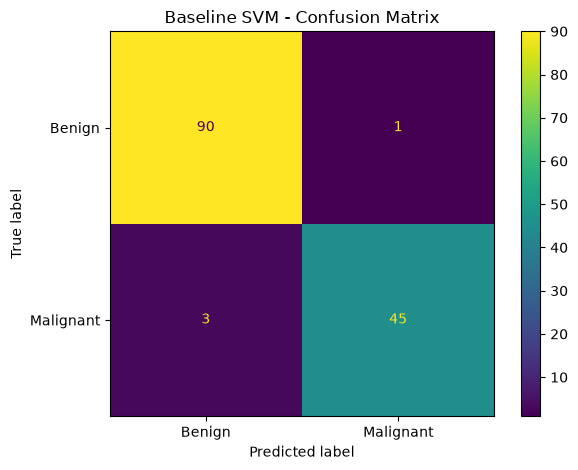

In [84]:
# ============================================================
# BASELINE SVM CONFUSION MATRIX PLOT
# ============================================================

# Create a visual confusion matrix for the baseline model.
ConfusionMatrixDisplay(
    confusion_matrix=final_svm_baseline_cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
).plot(
    values_format="d"
)


# Add a descriptive title.
plt.title(
    "Baseline SVM - Confusion Matrix"
)

plt.tight_layout()
plt.show()

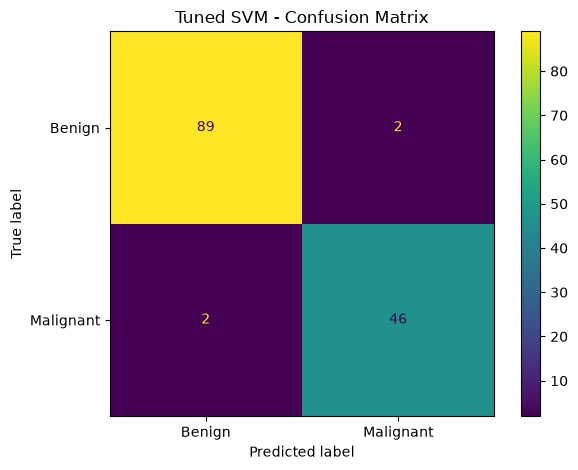

In [85]:
# ============================================================
# TUNED SVM CONFUSION MATRIX PLOT
# ============================================================

# Create a visual confusion matrix for the tuned model.
ConfusionMatrixDisplay(
    confusion_matrix=final_svm_tuned_cm,
    display_labels=[
        "Benign",
        "Malignant"
    ]
).plot(
    values_format="d"
)


# Add a descriptive title.
plt.title(
    "Tuned SVM - Confusion Matrix"
)

plt.tight_layout()
plt.show()

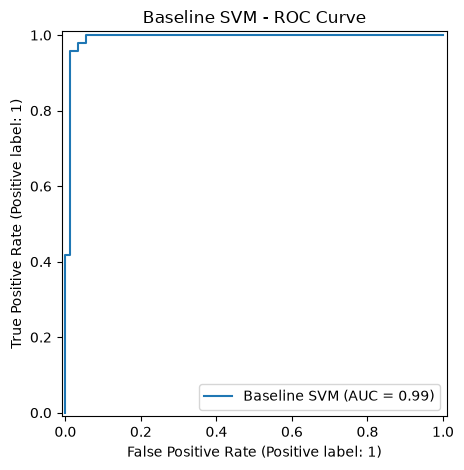

In [86]:
# ============================================================
# BASELINE SVM ROC CURVE
# ============================================================

# Plot the ROC curve using baseline SVM decision scores.
RocCurveDisplay.from_predictions(
    final_y_test,
    final_svm_baseline_score,
    name="Baseline SVM"
)


plt.title(
    "Baseline SVM - ROC Curve"
)

plt.tight_layout()
plt.show()

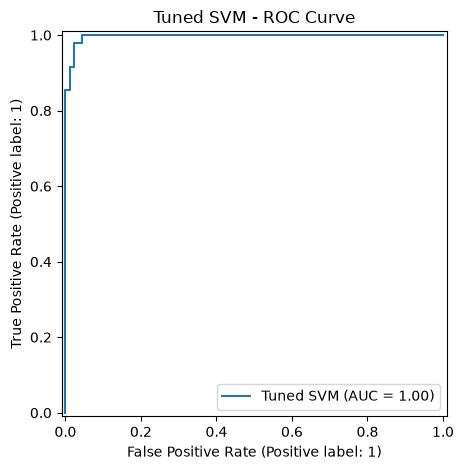

In [87]:
# ============================================================
# TUNED SVM ROC CURVE
# ============================================================

# Plot the ROC curve using tuned SVM decision scores.
RocCurveDisplay.from_predictions(
    final_y_test,
    final_svm_tuned_score,
    name="Tuned SVM"
)


plt.title(
    "Tuned SVM - ROC Curve"
)

plt.tight_layout()
plt.show()

In [88]:
# ============================================================
# CREATE BASELINE VS TUNED CROSS-VALIDATION SUMMARY
# ============================================================

# Store the mean CV scores for the baseline and tuned SVM.
final_svm_cv_summary = pd.DataFrame({

    "Model": [
        "Baseline SVM",
        "Tuned SVM"
    ],

    "Accuracy_Mean": [
        final_svm_baseline_cv[
            "test_accuracy"
        ].mean(),

        final_svm_tuned_cv[
            "test_accuracy"
        ].mean()
    ],

    "Accuracy_STD": [
        final_svm_baseline_cv[
            "test_accuracy"
        ].std(),

        final_svm_tuned_cv[
            "test_accuracy"
        ].std()
    ],

    "Precision_Mean": [
        final_svm_baseline_cv[
            "test_precision"
        ].mean(),

        final_svm_tuned_cv[
            "test_precision"
        ].mean()
    ],

    "Recall_Mean": [
        final_svm_baseline_cv[
            "test_recall"
        ].mean(),

        final_svm_tuned_cv[
            "test_recall"
        ].mean()
    ],

    "F1_Mean": [
        final_svm_baseline_cv[
            "test_f1"
        ].mean(),

        final_svm_tuned_cv[
            "test_f1"
        ].mean()
    ],

    "F1_STD": [
        final_svm_baseline_cv[
            "test_f1"
        ].std(),

        final_svm_tuned_cv[
            "test_f1"
        ].std()
    ],

    "ROC_AUC_Mean": [
        final_svm_baseline_cv[
            "test_roc_auc"
        ].mean(),

        final_svm_tuned_cv[
            "test_roc_auc"
        ].mean()
    ]
})


display(
    final_svm_cv_summary.round(4)
)

,Model,Accuracy_Mean,Accuracy_STD,Precision_Mean,Recall_Mean,F1_Mean,F1_STD,ROC_AUC_Mean
0,Baseline SVM,0.9638,0.0113,0.9337,0.9632,0.9480,0.0169,0.9895
1,Tuned SVM,0.9674,0.0092,0.9389,0.9684,0.9532,0.0136,0.9946


In [89]:
# ============================================================
# SAVE MEMBER 06 FINAL-EVALUATION RESULTS
# ============================================================

# pathlib is used to create and manage the output folder.
from pathlib import Path


# Create a separate directory for Member 06 final results.
final_svm_output_dir = Path(
    "results/member_06"
)


# Create the directory if it does not already exist.
final_svm_output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# SAVE BASELINE VS TUNED TEST RESULTS
# ------------------------------------------------------------

final_svm_comparison.to_csv(
    final_svm_output_dir /
    "svm_baseline_vs_tuned.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE CROSS-VALIDATION SUMMARY
# ------------------------------------------------------------

final_svm_cv_summary.to_csv(
    final_svm_output_dir /
    "svm_cross_validation_summary.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE COMPLETE GRID SEARCH RESULTS
# ------------------------------------------------------------

final_svm_grid_results.to_csv(
    final_svm_output_dir /
    "svm_grid_search_results.csv",
    index=False
)


# ------------------------------------------------------------
# SAVE TOP HYPERPARAMETER CONFIGURATIONS
# ------------------------------------------------------------

final_svm_top_results.to_csv(
    final_svm_output_dir /
    "svm_top_configurations.csv",
    index=False
)


# ============================================================
# VERIFY SAVED FILES
# ============================================================

print(
    "Member 06 final results saved successfully."
)

print(
    "\nOutput directory:",
    final_svm_output_dir
)


print(
    "\nSaved files:"
)


for file_path in sorted(
    final_svm_output_dir.iterdir()
):

    print(
        "-",
        file_path.name
    )

Member 06 final results saved successfully.

Output directory: results\member_06

Saved files:
- svm_baseline_vs_tuned.csv
- svm_cross_validation_summary.csv
- svm_grid_search_results.csv
- svm_top_configurations.csv


## Final Conclusion – Member 06

Member 06 evaluated Support Vector Machine classification for predicting
whether a breast cancer observation is benign or malignant.

The final modelling dataset contained **691 unique observations** after
removing 8 exact duplicates from the original 699 observations.

The data was divided using a stratified 80/20 train-test split:

- **552 training observations**
- **139 testing observations**

A machine-learning pipeline was used containing:

**Median Imputation → StandardScaler → SVM**

The baseline SVM achieved a test accuracy of **0.9712**, recall of
**0.9375**, F1-score of **0.9574**, and ROC-AUC of **0.9922**.

Hyperparameter tuning evaluated **24 SVM configurations** using 5-fold
stratified cross-validation. The best configuration was:

- **C = 0.1**
- **Kernel = Linear**
- **Class Weight = Balanced**

The tuned SVM achieved:

- **Accuracy = 0.9712**
- **Precision = 0.9583**
- **Recall = 0.9583**
- **F1-score = 0.9583**
- **ROC-AUC = 0.9970**

The tuned model produced:

- **89 True Negatives**
- **2 False Positives**
- **2 False Negatives**
- **46 True Positives**

Compared with the baseline model, tuning reduced false negatives from
3 to 2 and increased malignant-class recall from 0.9375 to 0.9583.
This improvement occurred with a small precision trade-off because false
positives increased from 1 to 2.

The tuned SVM is retained as Member 06's final model because its
hyperparameters were selected using training-set cross-validation and it
provided a strong balance between precision and recall.

### Suitability of SVM

SVM is suitable for this dataset because it performs effectively on
small-to-medium-sized datasets and can construct strong decision boundaries
in multidimensional feature spaces. Both linear and nonlinear RBF decision
boundaries were investigated during tuning.

### Limitations

The dataset is relatively small and historical, so performance may not
generalize to modern or more diverse patient populations.

SVM models can also be less interpretable than simpler statistical models,
and their performance depends on preprocessing and hyperparameter choices.

### Possible Improvements

Future work could include:

- Evaluation using larger and more diverse datasets.
- External validation using independent datasets.
- Investigation of additional kernels and hyperparameter ranges.
- Probability calibration when reliable probability estimates are required.
- Explainability techniques for understanding individual predictions.

These results are intended for academic machine-learning evaluation and
should not be interpreted as evidence of clinical readiness.

In [90]:
# ============================================================
# MEMBER 06 - SVM
# Create folder for saving EDA visualizations
# ============================================================

from pathlib import Path

# Define the folder used to store all EDA plots
EDA_DIR = Path("results/eda_visualizations")

# Create the folder if it does not already exist
EDA_DIR.mkdir(parents=True, exist_ok=True)

print(f"EDA plots will be saved in: {EDA_DIR}")

EDA plots will be saved in: results\eda_visualizations
